In [2]:
import numpy as np
import pandas as pd

# =========================
# 1. Create Dummy Dataset
# =========================
np.random.seed(42)

n_customers = 500

first_names = [
    'James', 'Mary', 'John', 'Patricia', 'Robert', 'Jennifer',
    'Michael', 'Linda', 'William', 'Elizabeth', 'David', 'Susan',
    'Richard', 'Jessica', 'Joseph', 'Sarah', 'Thomas', 'Karen',
    'Charles', 'Nancy', 'Christopher', 'Lisa', 'Daniel', 'Margaret'
]

last_names = [
    'Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia',
    'Miller', 'Davis', 'Rodriguez', 'Martinez', 'Hernandez', 'Lopez',
    'Gonzalez', 'Wilson', 'Anderson', 'Thomas', 'Taylor', 'Moore',
    'Jackson', 'Martin', 'Lee', 'Perez', 'Thompson', 'White'
]

data = {
    'first_name': np.random.choice(first_names, n_customers),
    'last_name': np.random.choice(last_names, n_customers),
    'age': np.random.randint(18, 70, n_customers),
    'annual_income': np.random.randint(200, 1000, n_customers),
    'spending_score': np.random.randint(1, 100, n_customers),
}

df = pd.DataFrame(data)

print("Sample Data:")
print(df.head())

# =========================
# 2. Feature Selection
# =========================
features = df[['age', 'annual_income', 'spending_score']]

# =========================
# 3. Scaling
# =========================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# =========================
# 4. KMeans Clustering
# =========================
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['cluster'] = kmeans.fit_predict(X_scaled)

# =========================
# 5. Centroids (Original Scale)
# =========================
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids,
    columns=['age', 'annual_income', 'spending_score']
)

print("\nCluster Centroids:")
print(centroids_df)

# =========================
# 6. Cluster Naming Logic
# =========================
cluster_names = {}

for i, c in enumerate(centroids):
    age, income, spending = c

    if age < 30 and spending < 50:
        cluster_names[i] = "Young Low Spenders"
    elif age < 30 and spending >= 50:
        cluster_names[i] = "Young High Spenders"
    elif age >= 30 and spending < 50:
        cluster_names[i] = "Older Low Spenders"
    else:
        cluster_names[i] = "Older High Spenders"

df['cluster_name'] = df['cluster'].map(cluster_names)

# =========================
# 7. Final Output
# =========================
print("\nCluster Distribution:")
print(df['cluster_name'].value_counts())

print("\nFinal Data Sample:")
print(df.head())

# =========================
# 8. Prediction for New Customer
# =========================
# Format: [age, annual_income, spending_score]
new_customer = [[69, 850, 61]]

new_customer_scaled = scaler.transform(new_customer)
predicted_cluster = kmeans.predict(new_customer_scaled)

print("\nNew Customer Cluster ID:", predicted_cluster[0])
print("New Customer Segment:", cluster_names[predicted_cluster[0]])


Sample Data:
  first_name last_name  age  annual_income  spending_score
0    Michael  Thompson   64            768              53
1      Nancy   Johnson   18            696              55
2     Joseph    Taylor   43            211              32
3      David    Martin   31            517              51
4      Linda     White   55            791              44

Cluster Centroids:
         age  annual_income  spending_score
0  52.916031     406.229008       27.427481
1  57.477273     752.303030       66.303030
2  33.269231     778.980769       25.451923
3  30.954887     475.473684       68.759398

Cluster Distribution:
cluster_name
Older High Spenders    265
Older Low Spenders     235
Name: count, dtype: int64

Final Data Sample:
  first_name last_name  age  annual_income  spending_score  cluster  \
0    Michael  Thompson   64            768              53        1   
1      Nancy   Johnson   18            696              55        3   
2     Joseph    Taylor   43            211  

c:\Users\Administrator\Desktop\AI-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


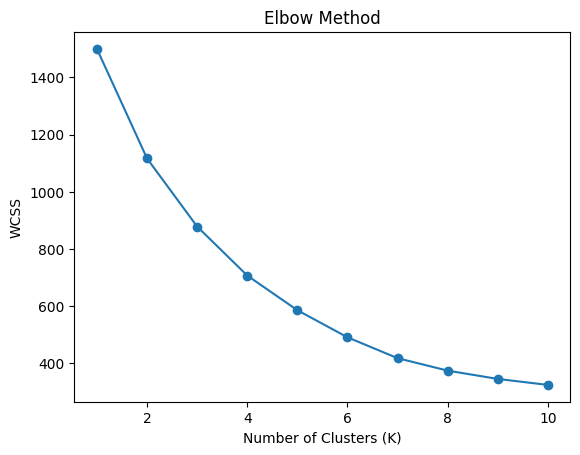


Cluster Distribution:
cluster_name
Older Low Spenders     250
Older High Spenders    130
Young Low Spenders     120
Name: count, dtype: int64

Sample Final Data:
  first_name last_name  age  annual_income  spending_score  cluster  \
0    Michael  Thompson   64     690.560232              85        3   
1      Nancy   Johnson   18     521.300667              26        0   
2     Joseph    Taylor   43      86.705212              72        0   
3      David    Martin   31     958.170793              48        2   
4      Linda     White   55     758.392414              66        3   

          cluster_name  
0  Older High Spenders  
1   Young Low Spenders  
2   Young Low Spenders  
3   Older Low Spenders  
4  Older High Spenders  

Predicted Cluster ID: 2
Predicted Segment: Older Low Spenders


c:\Users\Administrator\Desktop\AI-ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# =========================
# 1. Generate Dataset
# =========================
np.random.seed(42)
n_customers = 500

first_names = [
    'James', 'Mary', 'John', 'Patricia', 'Robert', 'Jennifer',
    'Michael', 'Linda', 'William', 'Elizabeth', 'David', 'Susan',
    'Richard', 'Jessica', 'Joseph', 'Sarah', 'Thomas', 'Karen',
    'Charles', 'Nancy', 'Christopher', 'Lisa', 'Daniel', 'Margaret'
]

last_names = [
    'Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Garcia',
    'Miller', 'Davis', 'Rodriguez', 'Martinez', 'Hernandez', 'Lopez',
    'Gonzalez', 'Wilson', 'Anderson', 'Thomas', 'Taylor', 'Moore',
    'Jackson', 'Martin', 'Lee', 'Perez', 'Thompson', 'White'
]

data = {
    'first_name': np.random.choice(first_names, n_customers),
    'last_name': np.random.choice(last_names, n_customers),
    'age': np.random.randint(18, 70, n_customers),
    'annual_income': np.random.random_sample(n_customers) * 1000,
    'spending_score': np.random.randint(1, 100, n_customers),
}

df = pd.DataFrame(data)

# =========================
# 2. Select Numeric Features
# =========================
X = df[['age', 'annual_income', 'spending_score']]

# =========================
# 3. Scale Data
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. Elbow Method (SEPARATE model)
# =========================
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# =========================
# 5. Final KMeans Model
# =========================
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# =========================
# 6. Centroids (Original Scale)
# =========================
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# =========================
# 7. Cluster Naming
# =========================
cluster_names = {}

for i, c in enumerate(centroids):
    age, income, spending = c

    if age <= 31 and spending < 50:
        cluster_names[i] = "Young Low Spenders"
    elif age <= 31 and spending >= 50:
        cluster_names[i] = "Young High Spenders"
    elif age > 31 and spending < 50:
        cluster_names[i] = "Older Low Spenders"
    else:
        cluster_names[i] = "Older High Spenders"

df['cluster_name'] = df['cluster'].map(cluster_names)

# =========================
# 8. Output
# =========================
print("\nCluster Distribution:")
print(df['cluster_name'].value_counts())

print("\nSample Final Data:")
print(df.head())

# =========================
# 9. Prediction (CORRECT)
# =========================
new_customer = [[56, 850, 16]]  # age, income, spending

new_customer_scaled = scaler.transform(new_customer)
predicted_cluster = kmeans.predict(new_customer_scaled)

print("\nPredicted Cluster ID:", predicted_cluster[0])
print("Predicted Segment:", cluster_names[predicted_cluster[0]])
